# FIG7: Inverse-dynamics accuracy of ANNet with noisy inputs, with and without low-pass filtering

This notebook regenerates manuscript Figure 7 from the packaged data archive `FIG7.zip` or `FIG7`.
The archive must be in the same folder as this notebook. Every plotted value is read from the archive, and the notebook asserts that no value falls outside the axes, then saves `FIG7.svg`, `FIG7.pdf` and `FIG7.png`.

Saved FIG7.svg


Saved FIG7.pdf


Saved FIG7.png


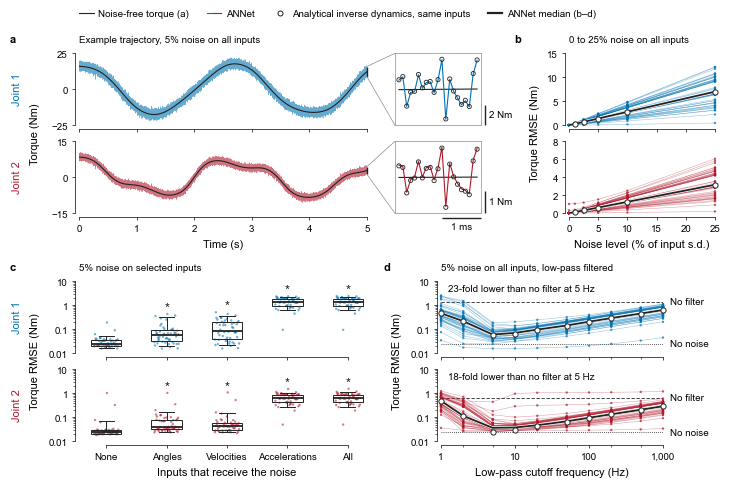

Panel b: 600 ANNet values drawn (50 trajectories per noise level and joint), range 0.0157 to 12.1708 Nm; analytical medians from 500 values.
Panel c: 500 ANNet values drawn (50 trajectories per joint without noise and for each input group at 5% noise).
Panel d: 1000 ANNet values drawn (50 trajectories per cutoff and joint) at 5% noise, range 0.0158 to 2.5847 Nm.
Example trajectory (panel a): index 11 of the fixed test set, 50001 time points; trajectory whose ANNet errors at this noise level (noise on all inputs) lie closest to the medians of both joints: smallest sum over the joints of |log(error / median error)|.
Noise model:
  zero-mean Gaussian, independent across inputs and time points; standard deviation = noise level times the standard deviation of that input over the trajectory (unbiased estimate over the 50,001 time points)
  levels (%) = [1.0, 2.5, 5.0, 10.0, 25.0], seed = 31
ANNet versus the analytical inverse dynamics on the same noisy inputs (primary test, FDR-adjusted):
jo

In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Load packaged data. FIG7.zip or FIG7 must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIG7.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIG7")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIG7.zip or FIG7 in the current folder. "
        "Place the data archive in the same folder as FIG7.ipynb."
    )

if DATA_ARCHIVE.is_dir():
    def open_member(name):
        return open(DATA_ARCHIVE / name, "rb")
else:
    _archive = zipfile.ZipFile(DATA_ARCHIVE)

    def open_member(name):
        return _archive.open(name)

# The tables are parsed with exact round-trip precision, so the values equal those the analysis notebook plotted
rmse_table = pd.read_csv(open_member("fig7_rmse_values.csv"), float_precision="round_trip")
stats_table = pd.read_csv(open_member("fig7_statistics.csv"), float_precision="round_trip")
group_stats_table = pd.read_csv(open_member("fig7_input_group_statistics.csv"), float_precision="round_trip")
scaling_table = pd.read_csv(open_member("fig7_scaling.csv"), float_precision="round_trip")
filter_table = pd.read_csv(open_member("fig7_filter_rmse.csv"), float_precision="round_trip")
filter_stats_table = pd.read_csv(open_member("fig7_filter_statistics.csv"), float_precision="round_trip")
traces_table = pd.read_csv(open_member("fig7_example_traces.csv"), float_precision="round_trip")
metadata = json.load(open_member("fig7_metadata.json"))
figure_percent = float(metadata["figure"]["noise_percent"])

import matplotlib.patheffects as pe
from matplotlib.legend_handler import HandlerTuple
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter
from matplotlib.transforms import blended_transform_factory

# -----------------------------------------------------------------------------
# Fig. 7 plotting code (the same drawing in MAIN_RUN_ME_NEW.ipynb and FIG7.ipynb).
# Two tiers, each with joint 1 (blue) above joint 2 (red).
# Upper tier, the example and the dependence on the noise level
# a: torques of the example trajectory over time. Noise-free torque (black) and torque
#    of ANNet for the noisy inputs (colour). The final 2 ms are expanded in the framed
#    view on the right, in which the line joins the ANNet torques of consecutive samples
#    and the open circles are the analytical inverse dynamics for the same noisy inputs.
# b: torque RMSE against the level of noise on all six inputs. Each thin line is one
#    test trajectory of ANNet, the heavy line joins the ANNet medians and open circles
#    are the medians of the analytical inverse dynamics on the same noisy inputs.
# Lower tier, the origin of the error and its remedy (one noise level, shared RMSE axis)
# c: box plots of the torque RMSE of ANNet when no input, one group of inputs, or all
#    inputs receive the noise, with every trajectory as a dot. An asterisk marks a
#    condition that differs from no noise (FDR q < 0.05), 'ns' one that does not.
# d: torque RMSE when the noisy inputs are low-pass filtered, against the cutoff.
# No value is removed, and the axes are asserted to enclose every plotted value.
# -----------------------------------------------------------------------------
FIG7_BLUE = '#0072B2'
FIG7_RED = '#B2182B'
FIG7_NEUTRAL = '#222222'
FIG7_GUIDE = '#8C8C8C'
FIG7_JOINTS = ['J1', 'J2']
FIG7_JOINT_COLORS = {'J1': FIG7_BLUE, 'J2': FIG7_RED}
# Panel c: inputs that receive the noise ('none' is the noise-free network)
FIG7_INPUT_GROUPS = ['none', 'angle', 'velocity', 'acceleration', 'all']
FIG7_INPUT_LABELS = {'none': 'None', 'angle': 'Angles', 'velocity': 'Velocities', 'acceleration': 'Accelerations',
                     'all': 'All'}
# Expanded view of panel a: number of consecutive samples at the end of the trajectory, and its time scale bar
FIG7_ZOOM_SAMPLES = 21
FIG7_ZOOM_BAR_MS = 1.0
# Symmetric limits of the torque axes of panel a (Nm)
FIG7_TORQUE_LIMITS = [1, 2, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100]
FIG7_RC = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.4,
    'ytick.minor.width': 0.4,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.minor.size': 1.4,
    'ytick.minor.size': 1.4,
    'xtick.major.pad': 2.5,
    'ytick.major.pad': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    # Export at the canvas size irrespective of the kernel's global rcParams
    'savefig.bbox': 'standard',
    'figure.dpi': 100,
    'savefig.dpi': 600,
}


def fig7_axis_top(maximum):
    # Smallest axis end on a 1-2-5 x 10^k tick step that encloses the data with at most four intervals
    for step in (0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0):
        intervals = int(np.ceil(maximum / step - 1e-9))
        if intervals <= 4:
            return intervals * step, step
    raise ValueError('value outside the supported range')


def fig7_decade_range(values):
    # Powers of ten that enclose the values
    return 10.0 ** np.floor(np.log10(np.min(values))), 10.0 ** np.ceil(np.log10(np.max(values)))


def fig7_number(value, _=None):
    return f"{value:,g}".replace('-', '−')


def draw_fig7(rmse_table, group_stats_table, filter_table, traces_table, figure_percent):
    """
    rmse_table:     long-form table with columns model, noise_target, noise_percent, joint, trajectory, rmse_nm.
    group_stats_table: one row per joint, noise level and noise condition with the columns noise_target and
                    significant_fdr_0_05 (ANNet errors under that condition against the noise-free ANNet errors).
    filter_table:   long-form table with columns model, noise_percent, cutoff_hz, joint, trajectory, rmse_nm
                    (noisy inputs low-pass filtered before they enter the model).
    traces_table:   one row per time point of the example trajectory with the columns time_s and, per joint,
                    noise_free_*_nm, annet_noisy_*_nm and analytical_noisy_*_nm.
    figure_percent: noise level (%) of the example trajectory and of panels c and d.
    Returns the matplotlib figure (four panels in two tiers, joint 1 above joint 2, double-column width).
    """
    levels = sorted(float(percent) for percent in
                    rmse_table.loc[rmse_table['noise_target'].isin(['none', 'all']), 'noise_percent'].unique())
    assert levels[0] == 0.0 and figure_percent in levels
    x_levels = np.asarray(levels)

    def select(model_name, noise_target, joint, percent):
        mask = ((rmse_table['model'] == model_name) & (rmse_table['noise_target'] == noise_target)
                & (rmse_table['joint'] == joint) & (rmse_table['noise_percent'] == percent))
        return rmse_table.loc[mask].sort_values('trajectory')['rmse_nm'].to_numpy(dtype=float)

    def select_filtered(model_name, joint, cutoff_hz):
        mask = ((filter_table['model'] == model_name) & (filter_table['noise_percent'] == figure_percent)
                & (filter_table['joint'] == joint) & (filter_table['cutoff_hz'] == cutoff_hz))
        return filter_table.loc[mask].sort_values('trajectory')['rmse_nm'].to_numpy(dtype=float)

    clean = {joint: select('ANNet', 'none', joint, 0.0) for joint in FIG7_JOINTS}
    annet = {joint: np.stack([clean[joint]] + [select('ANNet', 'all', joint, percent) for percent in levels[1:]])
             for joint in FIG7_JOINTS}
    analytical = {joint: np.stack([select('analytical', 'all', joint, percent) for percent in levels[1:]])
                  for joint in FIG7_JOINTS}
    cutoffs = np.asarray(sorted(float(cutoff) for cutoff in filter_table['cutoff_hz'].unique()))
    filtered = {joint: np.stack([select_filtered('ANNet', joint, cutoff) for cutoff in cutoffs]) for joint in FIG7_JOINTS}
    filtered_reference = {joint: np.asarray([np.median(select_filtered('analytical', joint, cutoff)) for cutoff in cutoffs])
                          for joint in FIG7_JOINTS}
    unfiltered = {joint: np.median(select('ANNet', 'all', joint, figure_percent)) for joint in FIG7_JOINTS}
    group_values = {(joint, group): clean[joint] if group == 'none' else select('ANNet', group, joint, figure_percent)
                    for joint in FIG7_JOINTS for group in FIG7_INPUT_GROUPS}

    # ---- geometry in inches, measured from the left and from the top of the canvas ----
    width, height = 7.2, 4.8
    fig = plt.figure(figsize=(width, height))
    row_height = 0.72
    row_top = {('upper', 'J1'): 0.50, ('upper', 'J2'): 1.38, ('lower', 'J1'): 2.78, ('lower', 'J2'): 3.66}
    columns = {'trace': ('upper', 0.72, 2.88), 'zoom': ('upper', 3.88, 0.86), 'fan': ('upper', 5.62, 1.46),
               'group': ('lower', 0.72, 2.96), 'filter': ('lower', 4.34, 2.22)}
    axes = {(name, joint): fig.add_axes([left / width, 1.0 - (row_top[(tier, joint)] + row_height) / height,
                                         span / width, row_height / height])
            for name, (tier, left, span) in columns.items() for joint in FIG7_JOINTS}
    for (name, joint), ax in axes.items():
        if name == 'zoom':
            continue
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        ax.spines['left'].set_position(('outward', 3))
        ax.spines['bottom'].set_position(('outward', 3))
    median_style = dict(color=FIG7_NEUTRAL, lw=1.3, solid_capstyle='butt',
                        path_effects=[pe.withStroke(linewidth=2.3, foreground='white')])
    circle_style = dict(facecolors='white', edgecolors=FIG7_NEUTRAL, linewidths=0.7)
    trajectory_line = dict(lw=0.4, alpha=0.4, zorder=2, clip_on=False)
    trajectory_dot = dict(s=3, edgecolors='none', alpha=0.7, zorder=3, clip_on=False)

    # ---- a: torques of the example trajectory over time, and its final samples on expanded scales ----
    time = traces_table['time_s'].to_numpy(dtype=float)
    zoom = slice(len(time) - FIG7_ZOOM_SAMPLES, len(time))
    step_s = time[1] - time[0]
    for joint in FIG7_JOINTS:
        color = FIG7_JOINT_COLORS[joint]
        # The traces are stored in single precision
        trace = {name: traces_table[f"{name}_{joint.lower()}_nm"].to_numpy(dtype=np.float32).astype(float)
                 for name in ('noise_free', 'annet_noisy', 'analytical_noisy')}
        ax = axes[('trace', joint)]
        ax.plot(time, trace['annet_noisy'], color=color, lw=0.3, alpha=0.6, zorder=2, rasterized=True)
        ax.plot(time, trace['noise_free'], color=FIG7_NEUTRAL, lw=0.8, zorder=3)
        largest = max(np.abs(trace['annet_noisy']).max(), np.abs(trace['noise_free']).max())
        limit = min(value for value in FIG7_TORQUE_LIMITS if value >= largest)
        assert largest <= limit
        ax.set_xlim(time[0], time[-1])
        ax.set_ylim(-limit, limit)
        ax.set_xticks(np.arange(time[0], time[-1] + 0.5, 1.0))
        ax.set_yticks([-limit, 0, limit])

        # Expanded view: a frame without axes that encloses the samples with a margin, scale bars for time and torque
        ax_zoom = axes[('zoom', joint)]
        drawn = np.concatenate([trace[name][zoom] for name in trace])
        z_pad = 0.1 * (drawn.max() - drawn.min())
        z_low, z_high = drawn.min() - z_pad, drawn.max() + z_pad
        assert (drawn > z_low).all() and (drawn < z_high).all()
        ax_zoom.plot(time[zoom], trace['noise_free'][zoom], color=FIG7_NEUTRAL, lw=0.8, zorder=2)
        ax_zoom.plot(time[zoom], trace['annet_noisy'][zoom], color=color, lw=0.8, zorder=3)
        ax_zoom.scatter(time[zoom], trace['analytical_noisy'][zoom], s=9, facecolors='none', edgecolors=FIG7_NEUTRAL,
                        linewidths=0.6, zorder=4)
        ax_zoom.set_xlim(time[zoom][0] - step_s, time[zoom][-1] + step_s)
        ax_zoom.set_ylim(z_low, z_high)
        ax_zoom.set_xticks([])
        ax_zoom.set_yticks([])
        for spine in ax_zoom.spines.values():
            spine.set_color(FIG7_GUIDE)
            spine.set_linewidth(0.5)
        # The expanded window on the full trace, joined to the frame
        ax.plot([time[-1]] * 2, [z_low, z_high], color=FIG7_NEUTRAL, lw=1.0, solid_capstyle='butt', zorder=6, clip_on=False)
        for y_trace, y_frame in ((z_low, 0.0), (z_high, 1.0)):
            fig.add_artist(ConnectionPatch(xyA=(time[-1], y_trace), coordsA=ax.transData, xyB=(0.0, y_frame),
                                           coordsB=ax_zoom.transAxes, color=FIG7_GUIDE, lw=0.5))
        bar_nm = max(value for value in (0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0) if value <= 0.4 * (z_high - z_low))
        beside = blended_transform_factory(ax_zoom.transAxes, ax_zoom.transData)
        ax_zoom.plot([1.05, 1.05], [z_low, z_low + bar_nm], transform=beside, color=FIG7_NEUTRAL, lw=1.0,
                     solid_capstyle='butt', clip_on=False)
        ax_zoom.text(1.09, z_low + 0.5 * bar_nm, f"{bar_nm:g} Nm", transform=beside, ha='left', va='center', fontsize=7)
    below = blended_transform_factory(axes[('zoom', 'J2')].transData, axes[('zoom', 'J2')].transAxes)
    bar_end = time[zoom][-1] + step_s
    axes[('zoom', 'J2')].plot([bar_end - FIG7_ZOOM_BAR_MS * 1e-3, bar_end], [-0.07, -0.07], transform=below,
                              color=FIG7_NEUTRAL, lw=1.0, solid_capstyle='butt', clip_on=False)
    axes[('zoom', 'J2')].text(bar_end - 0.5 * FIG7_ZOOM_BAR_MS * 1e-3, -0.12, f"{FIG7_ZOOM_BAR_MS:g} ms", transform=below,
                              ha='center', va='top', fontsize=7)
    axes[('trace', 'J2')].set_xlabel('Time (s)')

    # ---- b: every trajectory against the noise level, linear axes ----
    for joint in FIG7_JOINTS:
        ax = axes[('fan', joint)]
        color = FIG7_JOINT_COLORS[joint]
        y_top, y_step = fig7_axis_top(annet[joint].max())
        assert (annet[joint] >= 0.0).all() and (annet[joint] <= y_top).all()
        assert (np.median(analytical[joint], axis=1) <= y_top).all()
        for i in range(annet[joint].shape[1]):
            ax.plot(x_levels, annet[joint][:, i], color=color, **trajectory_line)
        ax.scatter(np.repeat(x_levels, annet[joint].shape[1]), annet[joint].ravel(), color=color, **trajectory_dot)
        ax.plot(x_levels, np.median(annet[joint], axis=1), zorder=5, clip_on=False, **median_style)
        ax.scatter(x_levels[1:], np.median(analytical[joint], axis=1), s=14, zorder=7, clip_on=False, **circle_style)
        ax.set_xlim(0.0, x_levels[-1])
        ax.set_ylim(0.0, y_top)
        ax.set_xticks(np.arange(0.0, x_levels[-1] + 2.5, 5.0))
        ax.set_yticks(np.arange(0.0, y_top + 0.5 * y_step, y_step))
    axes[('fan', 'J2')].set_xlabel('Noise level (% of input s.d.)')

    # ---- c and d share one logarithmic RMSE axis, bounded by powers of ten ----
    lower_values = np.hstack([values for values in group_values.values()]
                             + [filtered[joint].ravel() for joint in FIG7_JOINTS]
                             + [filtered_reference[joint] for joint in FIG7_JOINTS])
    y_low, y_high = fig7_decade_range(lower_values)
    assert (lower_values >= y_low).all() and (lower_values <= y_high).all()
    decades = 10.0 ** np.arange(np.log10(y_low), np.log10(y_high) + 0.5)
    between_decades = np.concatenate([decade * np.arange(2, 10) for decade in decades[:-1]])

    # ---- c: noise on no input, on one group of inputs or on all inputs, as box plots of the ANNet errors ----
    group_positions = np.arange(len(FIG7_INPUT_GROUPS), dtype=float)
    for joint in FIG7_JOINTS:
        ax = axes[('group', joint)]
        color = FIG7_JOINT_COLORS[joint]
        # Centre line, median; box, quartiles; whiskers, 5th and 95th percentiles (the same on linear and logarithmic axes)
        boxes = []
        for group in FIG7_INPUT_GROUPS:
            low, q1, median, q3, high = np.percentile(group_values[(joint, group)], [5, 25, 50, 75, 95])
            boxes.append(dict(whislo=low, q1=q1, med=median, q3=q3, whishi=high, fliers=[]))
        ax.bxp(boxes, positions=group_positions, widths=0.5, showfliers=False, patch_artist=True, manage_ticks=False, zorder=4,
               boxprops=dict(facecolor='none', edgecolor=FIG7_NEUTRAL, linewidth=0.7),
               whiskerprops=dict(color=FIG7_NEUTRAL, linewidth=0.7), capprops=dict(color=FIG7_NEUTRAL, linewidth=0.7),
               medianprops=dict(color=FIG7_NEUTRAL, linewidth=1.3, solid_capstyle='butt'))
        for position, group in zip(group_positions, FIG7_INPUT_GROUPS):
            values = group_values[(joint, group)]
            # Every trajectory, spread horizontally inside the box in the order of the test set
            offsets = (np.arange(len(values)) / (len(values) - 1) - 0.5) * 0.4
            ax.scatter(position + offsets, values, color=color, s=3, edgecolors='none', alpha=0.55, zorder=3, clip_on=False)
            if group != 'none':
                # Difference from the noise-free errors: one asterisk if significant after FDR correction, 'ns' otherwise
                row = group_stats_table[(group_stats_table['joint'] == joint) & (group_stats_table['noise_target'] == group)
                                        & (group_stats_table['noise_percent'] == figure_percent)]
                assert len(row) == 1
                significant = bool(row['significant_fdr_0_05'].iloc[0])
                mark_y = 1.7 * values.max()
                assert mark_y < y_high, 'the significance mark of panel c leaves the axes'
                ax.text(position, mark_y, '*' if significant else 'ns', ha='center', va='center',
                        fontsize=9 if significant else 7, color=FIG7_NEUTRAL)
        ax.set_yscale('log')
        ax.set_xlim(group_positions[0] - 0.45, group_positions[-1] + 0.45)
        ax.set_ylim(y_low, y_high)
        ax.set_xticks(group_positions)
        ax.spines['bottom'].set_bounds(group_positions[0], group_positions[-1])
    axes[('group', 'J2')].set_xticklabels([FIG7_INPUT_LABELS[group] for group in FIG7_INPUT_GROUPS])
    axes[('group', 'J2')].set_xlabel('Inputs that receive the noise')

    # ---- d: low-pass filtered noisy inputs against the cutoff frequency ----
    reference_labels = {}
    for joint in FIG7_JOINTS:
        ax = axes[('filter', joint)]
        color = FIG7_JOINT_COLORS[joint]
        for i in range(filtered[joint].shape[1]):
            ax.plot(cutoffs, filtered[joint][:, i], color=color, **trajectory_line)
        ax.scatter(np.repeat(cutoffs, filtered[joint].shape[1]), filtered[joint].ravel(), color=color, **trajectory_dot)
        ax.plot(cutoffs, np.median(filtered[joint], axis=1), zorder=5, clip_on=False, **median_style)
        ax.scatter(cutoffs, filtered_reference[joint], s=14, zorder=7, clip_on=False, **circle_style)
        # Reference levels: ANNet median without filtering (dashed) and without noise (dotted)
        ax.axhline(unfiltered[joint], color=FIG7_NEUTRAL, lw=0.6, linestyle=(0, (4, 2)), zorder=1)
        ax.axhline(np.median(clean[joint]), color=FIG7_NEUTRAL, lw=0.6, linestyle=(0, (1, 1.5)), zorder=1)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(cutoffs[0], cutoffs[-1])
        ax.set_ylim(y_low, y_high)
        ax.xaxis.set_major_locator(FixedLocator([tick for tick in (1, 10, 100, 1000, 10000) if cutoffs[0] <= tick <= cutoffs[-1]]))
        # Minor ticks mark the remaining cutoffs
        ax.xaxis.set_minor_locator(FixedLocator([cutoff for cutoff in cutoffs if np.log10(cutoff) % 1 > 1e-9]))
        ax.xaxis.set_minor_formatter(NullFormatter())
        beside = blended_transform_factory(ax.transAxes, ax.transData)
        reference_labels[joint] = [
            ax.text(1.03, unfiltered[joint], 'No filter', transform=beside, ha='left', va='center', fontsize=7),
            ax.text(1.03, np.median(clean[joint]), 'No noise', transform=beside, ha='left', va='center', fontsize=7)]
        # Largest reduction of the median error by the filter
        best = int(np.argmin(np.median(filtered[joint], axis=1)))
        fold = unfiltered[joint] / np.median(filtered[joint][best])
        reference_labels[joint].append(
            ax.text(1.25 * cutoffs[0], 0.72 * y_high, f"{fold:.0f}-fold lower than no filter at {cutoffs[best]:g} Hz",
                    ha='left', va='top', fontsize=7))
    axes[('filter', 'J2')].set_xlabel('Low-pass cutoff frequency (Hz)')

    # ---- shared styling ----
    for (name, joint), ax in axes.items():
        if name in ('group', 'filter'):
            ax.yaxis.set_major_locator(FixedLocator(decades))
            ax.yaxis.set_minor_locator(FixedLocator(between_decades))
            ax.yaxis.set_minor_formatter(NullFormatter())
        if name != 'zoom':
            ax.yaxis.set_major_formatter(FuncFormatter(fig7_number))
        if name not in ('group', 'zoom'):
            ax.xaxis.set_major_formatter(FuncFormatter(fig7_number))
        if joint == 'J1':
            ax.tick_params(labelbottom=False)

    # ---- axis labels shared by the two joints, joint tags, titles and panel letters ----
    def row_middle(tier, joint=None):
        top = row_top[(tier, joint or 'J1')]
        bottom = row_top[(tier, joint or 'J2')] + row_height
        return 1.0 - 0.5 * (top + bottom) / height

    for name, label, offset in (('trace', 'Torque (Nm)', 0.44), ('fan', 'Torque RMSE (Nm)', 0.34),
                                ('group', 'Torque RMSE (Nm)', 0.44), ('filter', 'Torque RMSE (Nm)', 0.44)):
        tier, left, _ = columns[name]
        fig.text((left - offset) / width, row_middle(tier), label, rotation=90, ha='center', va='center', fontsize=8)
    for tier in ('upper', 'lower'):
        for joint in FIG7_JOINTS:
            fig.text(0.10 / width, row_middle(tier, joint), f"Joint {joint[1]}", rotation=90, ha='center', va='center',
                     fontsize=8, color=FIG7_JOINT_COLORS[joint])
    titles = {
        'a': ('trace', 0.72, f"Example trajectory, {figure_percent:g}% noise on all inputs"),
        'b': ('fan', 0.58, f"{x_levels[0]:g} to {x_levels[-1]:g}% noise on all inputs"),
        'c': ('group', 0.72, f"{figure_percent:g}% noise on selected inputs"),
        'd': ('filter', 0.60, f"{figure_percent:g}% noise on all inputs, low-pass filtered"),
    }
    for letter, (name, offset, title) in titles.items():
        tier, left, _ = columns[name]
        title_y = 1.0 - (row_top[(tier, 'J1')] - 0.09) / height
        fig.text((left - offset + 0.03) / width, title_y, letter, fontsize=8, fontweight='bold', ha='left', va='bottom')
        fig.text(left / width, title_y, title, fontsize=7, ha='left', va='bottom')

    # ---- one key for the four panels ----
    handles = [
        Line2D([0], [0], color=FIG7_NEUTRAL, lw=0.8),
        (Line2D([0], [0], color=FIG7_BLUE, lw=0.8), Line2D([0], [0], color=FIG7_RED, lw=0.8)),
        Line2D([0], [0], marker='o', linestyle='None', markersize=3.6, markerfacecolor='white',
               markeredgecolor=FIG7_NEUTRAL, markeredgewidth=0.7),
        Line2D([0], [0], color=FIG7_NEUTRAL, lw=1.6),
    ]
    labels = ['Noise-free torque (a)', 'ANNet', 'Analytical inverse dynamics, same inputs', 'ANNet median (b\u2013d)']
    fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.72 / width, 1.0 - 0.06 / height), ncol=len(handles),
               frameon=False, handlelength=1.5, handletextpad=0.5, columnspacing=1.8, borderaxespad=0.0, borderpad=0.0,
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0.0)})

    # The annotations of panel d must not cover a plotted value
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for joint in FIG7_JOINTS:
        ax = axes[('filter', joint)]
        box = reference_labels[joint][2].get_window_extent(renderer).transformed(ax.transData.inverted())
        x_all = np.repeat(cutoffs, filtered[joint].shape[1])
        y_all = filtered[joint].ravel()
        covered = (x_all >= box.x0) & (x_all <= box.x1) & (y_all >= box.y0) & (y_all <= box.y1)
        assert not covered.any(), 'the text of panel d covers a plotted value'
        assert box.y0 > unfiltered[joint], 'the text of panel d meets the dashed line'
    return fig

mpl.rcParams.update(FIG7_RC)
fig = draw_fig7(rmse_table, group_stats_table, filter_table, traces_table, figure_percent)
for ext in ("svg", "pdf", "png"):
    path = Path(f"FIG7.{ext}")
    fig.savefig(path, facecolor="white")
    print(f"Saved {path}")
plt.show()

# Every archived value that belongs to a panel is drawn once
_levels = sorted(rmse_table["noise_percent"].unique())
_drawn = rmse_table[(rmse_table["model"] == "ANNet") & rmse_table["noise_target"].isin(["none", "all"])]
_reference = rmse_table[(rmse_table["model"] == "analytical") & (rmse_table["noise_target"] == "all")]
assert len(_drawn) == 100 * len(_levels) and _drawn.groupby(["noise_percent", "joint"]).trajectory.nunique().eq(50).all()
assert len(_reference) == 100 * (len(_levels) - 1) and _reference.groupby(["noise_percent", "joint"]).trajectory.nunique().eq(50).all()
print(f"Panel b: {len(_drawn)} ANNet values drawn (50 trajectories per noise level and joint), "
      f"range {_drawn.rmse_nm.min():.4f} to {_drawn.rmse_nm.max():.4f} Nm; analytical medians from {len(_reference)} values.")
_groups = rmse_table[(rmse_table["model"] == "ANNet") & ((rmse_table["noise_percent"] == figure_percent) | (rmse_table["noise_target"] == "none"))]
assert len(_groups) == 500 and _groups.groupby(["noise_target", "joint"]).trajectory.nunique().eq(50).all()
print(f"Panel c: {len(_groups)} ANNet values drawn (50 trajectories per joint without noise and for each input group at {figure_percent:g}% noise).")
_filtered = filter_table[(filter_table["model"] == "ANNet") & (filter_table["noise_percent"] == figure_percent)]
_cutoffs = sorted(filter_table["cutoff_hz"].unique())
assert len(_filtered) == 100 * len(_cutoffs) and _filtered.groupby(["cutoff_hz", "joint"]).trajectory.nunique().eq(50).all()
print(f"Panel d: {len(_filtered)} ANNet values drawn (50 trajectories per cutoff and joint) at {figure_percent:g}% noise, "
      f"range {_filtered.rmse_nm.min():.4f} to {_filtered.rmse_nm.max():.4f} Nm.")
print(f"Example trajectory (panel a): index {metadata['example_trajectory']['index']} of the fixed test set, "
      f"{len(traces_table)} time points; {metadata['example_trajectory']['selection_rule']}.")
print("Noise model:")
print(f"  {metadata['noise_model']['distribution']}; standard deviation = {metadata['noise_model']['standard_deviation']}")
print(f"  levels (%) = {metadata['noise_model']['noise_levels_percent']}, seed = {metadata['noise_model']['seed']}")
print("ANNet versus the analytical inverse dynamics on the same noisy inputs (primary test, FDR-adjusted):")
print(stats_table[["joint_label", "noise_percent", "test_name", "statistic", "p_value", "fdr_q_value",
                   "median_annet_nm", "median_analytical_nm", "median_ratio_annet_over_analytical",
                   "wilcoxon_paired_p_two_sided", "n_annet_higher"]].to_string(index=False))
print("Size of the effect and noise on one input group only (median ANNet error, Nm):")
print(stats_table[["joint_label", "noise_percent", "median_clean_annet_nm", "median_annet_percent_of_torque_sd",
                   "median_added_by_annet_nm", "median_annet_angle_noise_only_nm",
                   "median_annet_velocity_noise_only_nm", "median_annet_acceleration_noise_only_nm"]].to_string(index=False))
print(f"ANNet with noise on selected inputs against ANNet without noise at {figure_percent:g}% noise (primary test, FDR-adjusted across "
      f"{len(group_stats_table)} comparisons; {int(group_stats_table['significant_fdr_0_05'].sum())} significant):")
print(group_stats_table[group_stats_table["noise_percent"] == figure_percent][
    ["joint_label", "noise_target", "test_name", "p_value", "fdr_q_value", "significant_fdr_0_05", "median_annet_nm",
     "median_ratio_noisy_over_noise_free", "wilcoxon_paired_p_two_sided", "n_higher_than_noise_free"]].to_string(index=False))
print("Scaling law (medians over the 50 trajectories of each joint):")
print(scaling_table.groupby("joint")[["gain_first_order_nm_per_percent", "gain_annet_jacobian_nm_per_percent",
                                      "gain_fitted_analytical_nm_per_percent", "exponent_analytical", "exponent_annet",
                                      "max_relative_deviation_analytical_from_proportional_law",
                                      "max_relative_deviation_annet_from_quadrature_law"]].median().T.to_string())
print(f"Low-pass filtering: {metadata['filtering']['filter']}; cutoff = {metadata['filtering']['cutoff_definition']}; "
      f"{metadata['filtering']['end_extension']}.")
print("Cutoff with the lowest median ANNet error at each noise level (medians in Nm):")
print(filter_stats_table[filter_stats_table["lowest_median_annet_of_level"] & (filter_stats_table["noise_percent"] > 0)][
    ["joint_label", "noise_percent", "cutoff_hz", "median_unfiltered_annet_nm", "median_filtered_annet_nm",
     "median_filtered_analytical_nm", "reduction_factor_of_median_annet", "wilcoxon_filtered_vs_unfiltered_p_two_sided",
     "n_filtered_lower_than_unfiltered"]].to_string(index=False))
